# DNN com CIFAR-10 usando PyTorch (GPU)

Treinamento de uma rede neural profunda no CIFAR-10 com diferentes técnicas de otimização.

## Setup

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets

# Configurar device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# Carregar CIFAR-10
train_data = datasets.CIFAR10('./data', train=True, download=True)
test_data = datasets.CIFAR10('./data', train=False, download=True)

X_train_full = train_data.data.astype(np.float32).reshape(-1, 3072)
y_train_full = np.array(train_data.targets)
X_test = test_data.data.astype(np.float32).reshape(-1, 3072)
y_test = np.array(test_data.targets)

# Split train/valid
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Padronizar
mean, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mean) / std
X_valid = (X_valid - mean) / std
X_test = (X_test - mean) / std

# Converter para tensores
def to_tensor(X, y):
    return torch.FloatTensor(X), torch.LongTensor(y)

X_train, y_train = to_tensor(X_train, y_train)
X_valid, y_valid = to_tensor(X_valid, y_valid)
X_test, y_test = to_tensor(X_test, y_test)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Using: cuda
Train: torch.Size([45000, 3072]), Valid: torch.Size([5000, 3072]), Test: torch.Size([10000, 3072])


In [9]:
# Função de treinamento
def train(model, X_tr, y_tr, X_val, y_val, lr=1e-4, epochs=100, patience=10):
    model.to(device)
    optimizer = optim.NAdam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=128, shuffle=True)
    valid_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)
    
    history = {'train_acc': [], 'val_acc': []}
    best_val_loss, counter, best_state = float('inf'), 0, None
    
    for epoch in range(epochs):
        # Treino
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
        
        # Validação
        model.eval()
        with torch.no_grad():
            train_acc = (model(X_tr.to(device)).argmax(1) == y_tr.to(device)).float().mean().item()
            val_pred = model(X_val.to(device))
            val_loss = criterion(val_pred, y_val.to(device)).item()
            val_acc = (val_pred.argmax(1) == y_val.to(device)).float().mean().item()
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss, counter, best_state = val_loss, 0, model.state_dict().copy()
        else:
            counter += 1
            if counter >= patience:
                model.load_state_dict(best_state)
                print(f"Early stop at epoch {epoch}")
                break
    
    return model, history

## a) Modelo com ELU e inicialização He

In [10]:
model_a = nn.Sequential(
    nn.Linear(3072, 100), nn.ELU(), *[nn.Sequential(nn.Linear(100, 100), nn.ELU()) for _ in range(19)],
    nn.Linear(100, 10)
)

# Aplicar inicialização He
for layer in model_a:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight)

model_a, hist_a = train(model_a, X_train, y_train, X_valid, y_valid, lr=5e-5)

Epoch 0: Train Acc=0.188, Val Acc=0.200
Epoch 5: Train Acc=0.273, Val Acc=0.252
Epoch 10: Train Acc=0.366, Val Acc=0.325
Epoch 15: Train Acc=0.430, Val Acc=0.377
Epoch 20: Train Acc=0.470, Val Acc=0.392
Epoch 25: Train Acc=0.495, Val Acc=0.403
Epoch 30: Train Acc=0.523, Val Acc=0.406
Early stop at epoch 31


In [11]:
model_bn = nn.Sequential(
    nn.Linear(3072, 100, bias=False), nn.BatchNorm1d(100), nn.ELU(),
    *[nn.Sequential(nn.Linear(100, 100, bias=False), nn.BatchNorm1d(100), nn.ELU()) for _ in range(19)],
    nn.Linear(100, 10)
)

model_bn, hist_bn = train(model_bn, X_train, y_train, X_valid, y_valid, lr=1e-3)

Epoch 0: Train Acc=0.426, Val Acc=0.401
Epoch 5: Train Acc=0.548, Val Acc=0.507
Epoch 10: Train Acc=0.593, Val Acc=0.514
Epoch 15: Train Acc=0.672, Val Acc=0.548
Epoch 20: Train Acc=0.709, Val Acc=0.541
Epoch 25: Train Acc=0.757, Val Acc=0.541
Early stop at epoch 25


## c) Modelo com Batch Normalization

In [12]:
model_selu = nn.Sequential(
    nn.Linear(3072, 100), nn.SELU(), *[nn.Sequential(nn.Linear(100, 100), nn.SELU()) for _ in range(19)],
    nn.Linear(100, 10)
)

# Inicialização LeCun
for layer in model_selu:
    if isinstance(layer, nn.Linear):
        nn.init.normal_(layer.weight, 0, np.sqrt(1 / layer.in_features))

model_selu, hist_selu = train(model_selu, X_train, y_train, X_valid, y_valid, lr=1e-4)

Epoch 0: Train Acc=0.366, Val Acc=0.355
Epoch 5: Train Acc=0.501, Val Acc=0.454
Epoch 10: Train Acc=0.571, Val Acc=0.476
Epoch 15: Train Acc=0.613, Val Acc=0.488
Early stop at epoch 19


## d) Modelo com SELU e inicialização LeCun

In [13]:
# Modelo com AlphaDropout
layers = [nn.Linear(3072, 100), nn.SELU()]
for i in range(19):
    layers.extend([nn.Linear(100, 100), nn.SELU()])
    if i % 5 == 0:
        layers.append(nn.AlphaDropout(0.1))
layers.append(nn.Linear(100, 10))

model_drop = nn.Sequential(*layers)
for layer in model_drop:
    if isinstance(layer, nn.Linear):
        nn.init.normal_(layer.weight, 0, np.sqrt(1 / layer.in_features))

model_drop, hist_drop = train(model_drop, X_train, y_train, X_valid, y_valid, lr=1e-4)

# MC Dropout (sem re-treinar)
model_drop.eval()
for m in model_drop.modules():
    if isinstance(m, nn.AlphaDropout):
        m.train()

with torch.no_grad():
    mc_preds = torch.stack([torch.softmax(model_drop(X_test.to(device)), 1) for _ in range(100)])
    mc_acc = (mc_preds.mean(0).argmax(1) == y_test.to(device)).float().mean()
    print(f"MC Dropout Test Accuracy: {mc_acc:.4f}")

Epoch 0: Train Acc=0.359, Val Acc=0.350
Epoch 5: Train Acc=0.477, Val Acc=0.444
Epoch 10: Train Acc=0.531, Val Acc=0.478
Epoch 15: Train Acc=0.565, Val Acc=0.501
Epoch 20: Train Acc=0.595, Val Acc=0.514
Epoch 25: Train Acc=0.615, Val Acc=0.519
Epoch 30: Train Acc=0.638, Val Acc=0.516
Early stop at epoch 32
MC Dropout Test Accuracy: 0.5315


## e) Modelo com AlphaDropout e MC Dropout

In [14]:
# One Cycle LR
def train_onecycle(model, X_tr, y_tr, X_val, y_val, max_lr=0.05, epochs=15):
    model.to(device)
    optimizer = optim.NAdam(model.parameters(), lr=max_lr)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=128, shuffle=True)
    
    total_steps = len(train_loader) * epochs
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr, total_steps=total_steps)
    
    history = {'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
        
        model.eval()
        with torch.no_grad():
            train_acc = (model(X_tr.to(device)).argmax(1) == y_tr.to(device)).float().mean().item()
            val_acc = (model(X_val.to(device)).argmax(1) == y_val.to(device)).float().mean().item()
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")
    
    return model, history

model_1cycle = nn.Sequential(
    nn.Linear(3072, 100, bias=False), nn.BatchNorm1d(100), nn.ELU(),
    *[nn.Sequential(nn.Linear(100, 100, bias=False), nn.BatchNorm1d(100), nn.ELU()) for _ in range(19)],
    nn.Linear(100, 10)
)

model_1cycle, hist_1cycle = train_onecycle(model_1cycle, X_train, y_train, X_valid, y_valid)

Epoch 0: Train Acc=0.330, Val Acc=0.321
Epoch 1: Train Acc=0.325, Val Acc=0.313
Epoch 2: Train Acc=0.382, Val Acc=0.366
Epoch 3: Train Acc=0.292, Val Acc=0.266
Epoch 4: Train Acc=0.449, Val Acc=0.419
Epoch 5: Train Acc=0.394, Val Acc=0.357
Epoch 6: Train Acc=0.497, Val Acc=0.447
Epoch 7: Train Acc=0.556, Val Acc=0.502
Epoch 8: Train Acc=0.582, Val Acc=0.517
Epoch 9: Train Acc=0.604, Val Acc=0.513
Epoch 10: Train Acc=0.634, Val Acc=0.526
Epoch 11: Train Acc=0.672, Val Acc=0.544
Epoch 12: Train Acc=0.695, Val Acc=0.545
Epoch 13: Train Acc=0.712, Val Acc=0.553
Epoch 14: Train Acc=0.715, Val Acc=0.551


## f) Modelo com One Cycle LR

## Comparação de Resultados

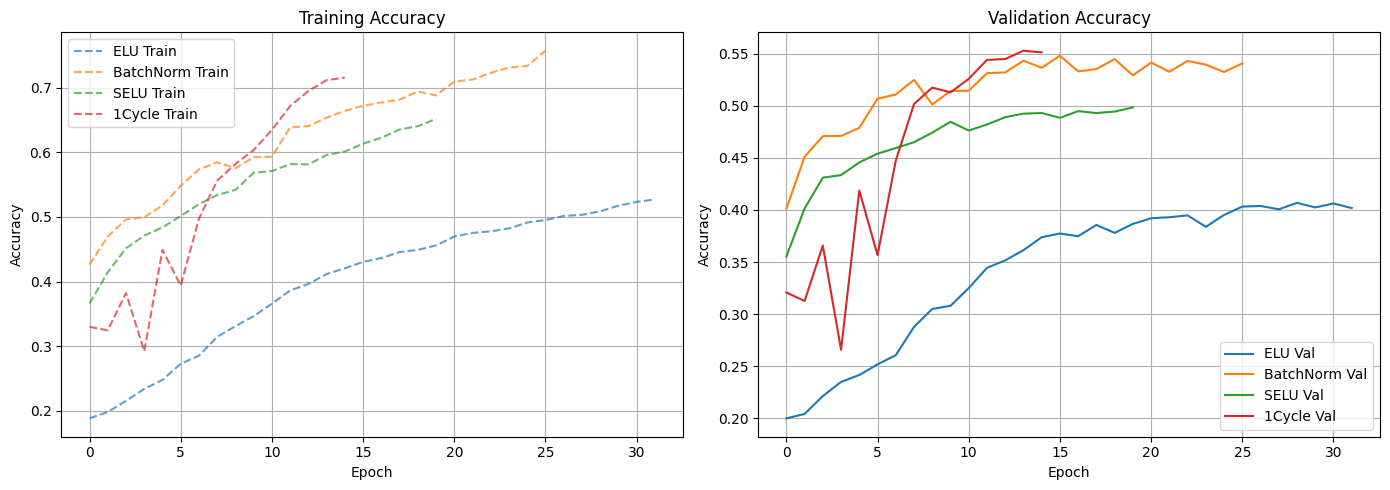

In [15]:
# Plotar curvas de aprendizado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

histories = [hist_a, hist_bn, hist_selu, hist_1cycle]
labels = ['ELU', 'BatchNorm', 'SELU', '1Cycle']

for hist, label in zip(histories, labels):
    ax1.plot(hist['train_acc'], label=f'{label} Train', linestyle='--', alpha=0.7)
    ax2.plot(hist['val_acc'], label=f'{label} Val')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training Accuracy')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Avaliação no Teste

In [16]:
# Avaliar modelos no teste
models = [('ELU', model_a), ('BatchNorm', model_bn), ('SELU', model_selu), 
          ('Dropout', model_drop), ('1Cycle', model_1cycle)]

print("Test Accuracy:")
print("-" * 40)
for name, model in models:
    model.eval()
    with torch.no_grad():
        acc = (model(X_test.to(device)).argmax(1) == y_test.to(device)).float().mean()
    print(f"{name:12s}: {acc:.4f} ({acc*100:.2f}%)")

Test Accuracy:
----------------------------------------
ELU         : 0.4032 (40.32%)
BatchNorm   : 0.5346 (53.46%)
SELU        : 0.4992 (49.92%)
Dropout     : 0.5254 (52.54%)
1Cycle      : 0.5485 (54.85%)
